In [78]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [79]:
# Load the dataset

path_1 ="data/financial_impact.csv"
path_2 ="data/incidents_master.csv"
path_3 ="data/market_impact.csv"
data_finan = pd.read_csv(path_1)
data_incident = pd.read_csv(path_2)
data_market = pd.read_csv(path_3)

In [80]:
df = pd.merge(data_finan, data_incident, on='incident_id')
df_final = pd.merge(df, data_market, on='incident_id', how = "outer")
df_final

,incident_id,direct_loss_usd,direct_loss_method,ransom_demanded_usd,ransom_paid_usd,ransom_source,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,insurance_payout_usd,...,p_value_30d,earnings_announcement_within_7d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,days_to_price_recovery,notes,created_at,updated_at
0,2021-0101-001,4967279.14,disclosed,9698485.95,5717211.61,company statement,2488838.05,1127543.48,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-0109-001,2066546.90,estimated,NaN,NaN,NaN,1829572.96,600867.65,NaN,1678410.68,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-0111-001,1600000.00,calculated,NaN,NaN,NaN,584549.71,406861.16,NaN,564566.39,...,1.00000,False,3.861498e+09,2.3269,0.020707,0.031208,49.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
3,2021-0117-001,2827335.54,calculated,2193976.56,1738883.24,blockchain analysis,2387941.53,474124.37,NaN,NaN,...,0.85785,False,1.378666e+09,2.7503,0.030143,0.034480,325.0,Elevated options activity detected 10 days bef...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
4,2021-0120-001,78022211.29,disclosed,1397414.98,804045.32,blockchain analysis,44863921.70,21170665.28,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
802,2025-1226-001,5119285.75,disclosed,NaN,NaN,NaN,3553590.95,1633789.43,NaN,2543920.34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
803,2025-1226-002,4760046.30,calculated,108866.54,NaN,NaN,4843245.47,362343.15,302251.9,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
804,2025-1227-001,43536609.85,estimated,NaN,NaN,NaN,42245003.39,8910659.60,NaN,47202487.06,...,1.00000,False,3.164782e+10,2.5244,0.010872,0.020354,144.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
805,2025-1231-001,9944830.62,disclosed,93173.95,NaN,NaN,10655366.28,896669.47,NaN,7135514.59,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [81]:
print("Finance Data", data_finan.shape)
print("Incident Data", data_incident.shape)
print("Market Data", data_market.shape)

print("Merge Data", df_final.shape)

Finance Data (778, 19)
Incident Data (850, 32)
Market Data (358, 31)
Merge Data (807, 80)


In [82]:
# list of columns to drop based on correlation analysis
cols_to_drop = [
    # redundant loss-related features
    "direct_loss_usd",
    "recovery_cost_usd",
    "legal_fees_usd",
    "total_loss_lower_bound",
    "total_loss_upper_bound",
    "inflation_adjusted_usd",

    # volatility duplication
    "post_incident_volatility_30d",

    # redundant price columns
    "price_7d_before",
    "price_disclosure_day",   # keep this if you prefer, otherwise remove others
    "price_1d_after",
    "price_7d_after",
    "price_30d_after",

    # duplicate abnormal return metrics
    "abnormal_return_1d",
    "abnormal_return_7d",
    "abnormal_return_30d",

    # statistical noise (not useful for ML models)
    "p_value_1d",
    "p_value_30d",
    "t_statistic_1d",
    "t_statistic_30d"
]

# drop columns safely (ignore errors if any column is missing)
df_final = df_final.drop(columns=cols_to_drop, errors='ignore')

# check result
print("Remaining columns:", df_final.columns.tolist())
print("Shape after cleanup:", df_final.shape)

Remaining columns: ['incident_id', 'direct_loss_method', 'ransom_demanded_usd', 'ransom_paid_usd', 'ransom_source', 'regulatory_fine_usd', 'insurance_payout_usd', 'total_loss_usd', 'total_loss_method', 'cpi_index_used', 'notes_x', 'created_at_x', 'updated_at_x', 'company_name', 'company_revenue_usd', 'country_hq', 'industry_primary', 'industry_secondary', 'employee_count', 'is_public_company', 'stock_ticker_x', 'incident_date', 'incident_date_estimated', 'discovery_date', 'disclosure_date', 'attack_vector_primary', 'attack_vector_secondary', 'attack_chain', 'attributed_group', 'attribution_confidence', 'data_compromised_records', 'data_type', 'systems_affected', 'downtime_hours', 'data_source_primary', 'data_source_secondary', 'data_source_type', 'confidence_tier', 'quality_score', 'quality_grade', 'review_flag', 'notes_y', 'created_at_y', 'updated_at_y', 'stock_ticker_y', 'volume_avg_30d_baseline', 'volume_disclosure_day', 'sector_index', 'sector_return_same_period', 'car_neg1_to_pos1

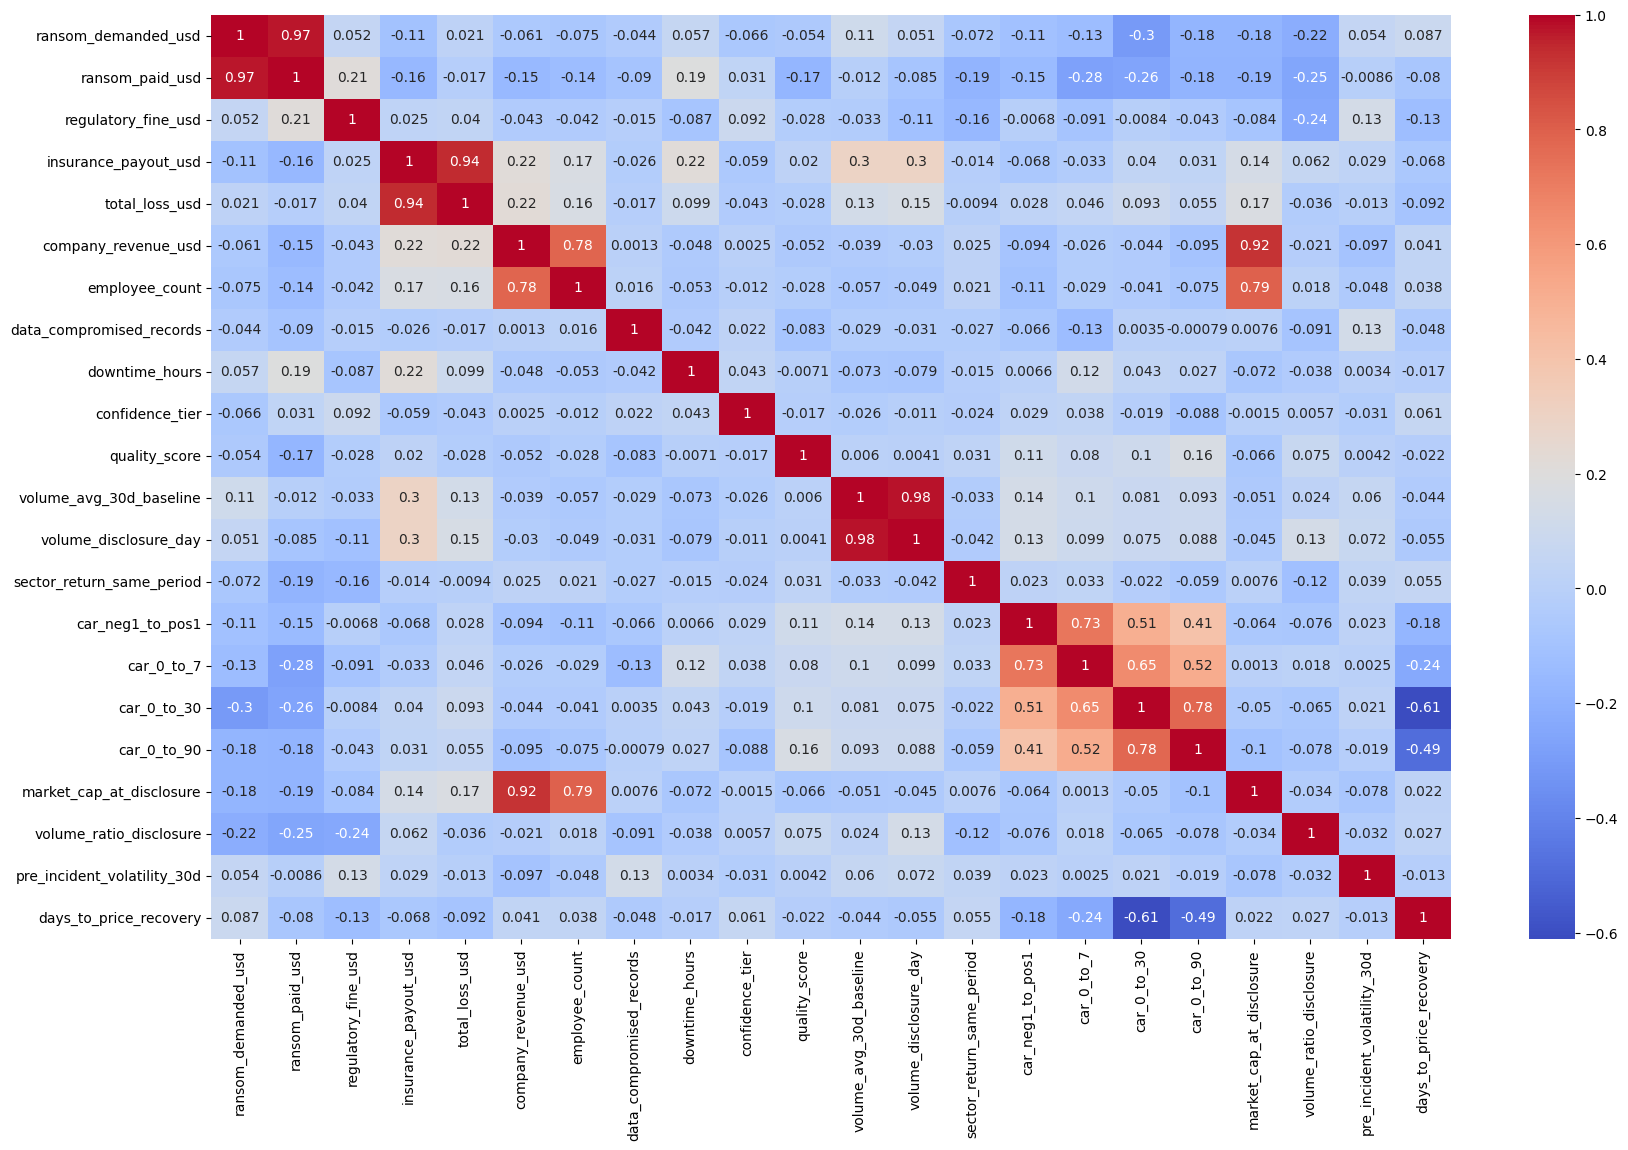

In [83]:
plt.figure(figsize=(20, 12))


import seaborn as sns
num_columns = df_final.select_dtypes(include=['number']).columns
cat_columns = df_final.select_dtypes(include=['object']).columns
df_final[num_columns] = df_final[num_columns]
corr_matrix = df_final[num_columns].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.show()

In [84]:
corr_matrix.sort_values(by = "days_to_price_recovery", ascending = False)

,ransom_demanded_usd,ransom_paid_usd,regulatory_fine_usd,insurance_payout_usd,total_loss_usd,company_revenue_usd,employee_count,data_compromised_records,downtime_hours,confidence_tier,...,volume_disclosure_day,sector_return_same_period,car_neg1_to_pos1,car_0_to_7,car_0_to_30,car_0_to_90,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,days_to_price_recovery
days_to_price_recovery,0.087475,-0.080093,-0.132282,-0.067531,-0.092385,0.040642,0.038270,-0.047903,-0.017354,0.061282,...,-0.055028,0.054814,-0.175723,-0.238550,-0.610715,-0.486885,0.022267,0.026544,-0.013077,1.000000
ransom_demanded_usd,1.000000,0.973830,0.051579,-0.105884,0.021372,-0.061248,-0.075097,-0.044054,0.057171,-0.065667,...,0.050733,-0.072315,-0.107588,-0.134017,-0.304594,-0.180293,-0.178827,-0.215271,0.053768,0.087475
confidence_tier,-0.065667,0.031475,0.091876,-0.058630,-0.042654,0.002514,-0.011525,0.022001,0.043263,1.000000,...,-0.010655,-0.024214,0.028976,0.038287,-0.019158,-0.087572,-0.001544,0.005728,-0.030762,0.061282
sector_return_same_period,-0.072315,-0.187149,-0.160185,-0.014274,-0.009380,0.024654,0.021441,-0.027141,-0.015104,-0.024214,...,-0.041797,1.000000,0.023340,0.032506,-0.022141,-0.058502,0.007629,-0.116239,0.038980,0.054814
company_revenue_usd,-0.061248,-0.153921,-0.042877,0.218534,0.220818,1.000000,0.780167,0.001313,-0.048336,0.002514,...,-0.030116,0.024654,-0.093876,-0.026161,-0.044426,-0.095033,0.919401,-0.020626,-0.096564,0.040642
employee_count,-0.075097,-0.135935,-0.042401,0.169273,0.162613,0.780167,1.000000,0.015661,-0.053339,-0.011525,...,-0.049331,0.021441,-0.105392,-0.029113,-0.040585,-0.074718,0.793216,0.017923,-0.048405,0.038270
volume_ratio_disclosure,-0.215271,-0.254807,-0.242496,0.061683,-0.035749,-0.020626,0.017923,-0.091057,-0.038351,0.005728,...,0.132911,-0.116239,-0.075899,0.017748,-0.065127,-0.077587,-0.033619,1.000000,-0.032399,0.026544
market_cap_at_disclosure,-0.178827,-0.185996,-0.084414,0.141727,0.173857,0.919401,0.793216,0.007638,-0.071857,-0.001544,...,-0.045041,0.007629,-0.063799,0.001254,-0.049698,-0.101869,1.000000,-0.033619,-0.078313,0.022267
pre_incident_volatility_30d,0.053768,-0.008589,0.134781,0.029126,-0.012511,-0.096564,-0.048405,0.126622,0.003372,-0.030762,...,0.071957,0.038980,0.022554,0.002485,0.020852,-0.018928,-0.078313,-0.032399,1.000000,-0.013077
downtime_hours,0.057171,0.191484,-0.087040,0.218675,0.098966,-0.048336,-0.053339,-0.042134,1.000000,0.043263,...,-0.079449,-0.015104,0.006560,0.122842,0.042922,0.026967,-0.071857,-0.038351,0.003372,-0.017354


In [85]:
for col in cat_columns:
    print(col, df_final[col].nunique())

incident_id 807
direct_loss_method 3
ransom_source 6
total_loss_method 3
cpi_index_used 5
notes_x 143
created_at_x 1
updated_at_x 1
company_name 693
country_hq 38
industry_primary 20
industry_secondary 19
is_public_company 2
stock_ticker_x 334
incident_date 642
incident_date_estimated 2
discovery_date 635
disclosure_date 645
attack_vector_primary 9
attack_vector_secondary 9
attack_chain 9
attributed_group 31
attribution_confidence 4
data_type 6
systems_affected 582
data_source_primary 778
data_source_secondary 352
data_source_type 5
quality_grade 3
review_flag 2
notes_y 60
created_at_y 1
updated_at_y 1
stock_ticker_y 317
sector_index 10
earnings_announcement_within_7d 2
notes 24
created_at 1
updated_at 1


In [86]:
df_final['incident_year'] = pd.to_datetime(df_final['incident_date']).dt.year
df_final['incident_month'] = pd.to_datetime(df_final['incident_date']).dt.month

df_final['disclosure_delay_days'] = (
    pd.to_datetime(df_final['disclosure_date']) - 
    pd.to_datetime(df_final['incident_date'])
).dt.days

df_final['discovery_delay_days'] = (
    pd.to_datetime(df_final['discovery_date']) - 
    pd.to_datetime(df_final['incident_date'])
).dt.days


cols_to_drop = [
    # IDs
    "incident_id",
    "company_name",
    "stock_ticker_x",

    # text
    "notes_x",
    "notes",
    "systems_affected",

    # timestamps
    "created_at_x",
    "updated_at_x",
    "created_at",
    "updated_at",

    # raw dates (after feature engineering)
    "incident_date",
    "discovery_date",
    "disclosure_date"
]

df_final = df_final.drop(columns=cols_to_drop, errors='ignore')